In [189]:
import os

In [190]:
os.getcwd()

'D:\\Flagship Projects'

In [191]:
os.chdir("D:\Flagship Projects")

In [192]:
os.getcwd()

'D:\\Flagship Projects'

In [193]:
import pandas as pd

In [194]:
import numpy as np

In [195]:
# Visualization
import matplotlib.pyplot as plt

In [196]:
import seaborn as sns

In [197]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             accuracy_score)

In [198]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [199]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [200]:
df = pd.read_csv('D:\Flagship Projects\Churn Prediuction\Telco-Customer-Churn.csv')

In [201]:
# First look at data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [202]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [203]:
df.isnull().sum()
## How many empty cells are there?

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [204]:
df["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [205]:
df['Churn'].value_counts(normalize=True)*100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

In [206]:
 ## Find Patterns (EDA Plots)

<AxesSubplot:>

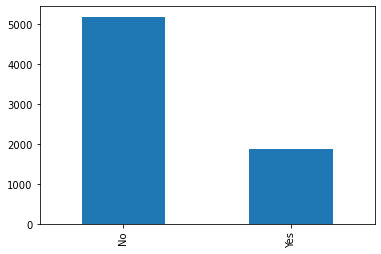

In [207]:
# Plot 1
df['Churn'].value_counts().plot(kind='bar')

# "How many churned vs stayed?"
         #Simple bar chart of Yes/No

<AxesSubplot:xlabel='tenure', ylabel='Count'>

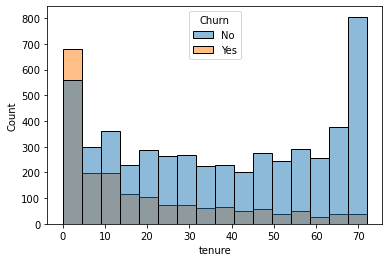

In [208]:
# Plot 2
sns.histplot(data=df, x='tenure', hue='Churn')

#"Do new customers churn more?"
    #@ompare tenure for churned vs stayed
    #Finding: Yes! New customers leave more!

<AxesSubplot:xlabel='Churn', ylabel='MonthlyCharges'>

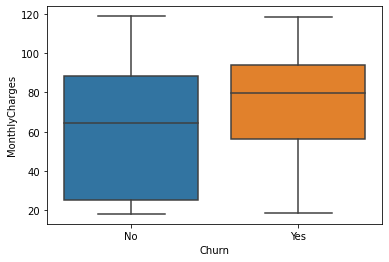

In [209]:
# Plot 3
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
#Do high paying customers leave more?"
         #Compare charges for churned vs stayed
         #Finding: Yes! Higher charges = more churn!


<AxesSubplot:xlabel='Contract', ylabel='count'>

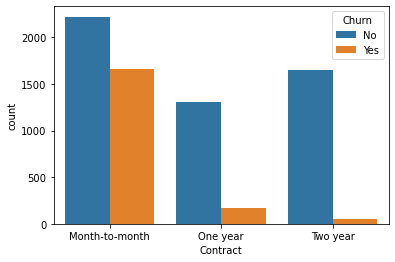

In [210]:
# Plot 4
sns.countplot(data=df, x='Contract', hue='Churn')

# "Which contract type churns most?"
         #Compare contract for churned vs stayed
         #Finding: Month-to-month = highest churn!

In [211]:
# ===============================================
# CELL 10 - FEATURE ENGINEERING
# Goal: Clean data and convert everything
#       into numbers for the ML model
# ===============================================


In [212]:
# PART 1 - FIX TOTALCHARGES COLUMN
# Step 1: Check what data type TotalCharges is
# We expect a number but it might be stored as text

In [213]:
print("Before fix:", df['TotalCharges'].dtype)

Before fix: object


In [214]:
# Step 2: Convert TotalCharges from TEXT to NUMBER
# "29.85" (text) → 29.85 (number)
# errors='coerce' means: if any value can't be
# converted, put NaN (empty) instead of crashing


In [215]:
df['TotalCharges'] = pd.to_numeric(
                     df['TotalCharges'],
                     errors='coerce')

In [216]:
# Step 3: Confirm the fix worked
print("After fix:", df['TotalCharges'].dtype)

After fix: float64


In [217]:
# Step 4: Check how many empty values were created
# Some blank rows become NaN after conversion


In [218]:
print("Empty values:", df['TotalCharges'].isnull().sum())

Empty values: 11


In [219]:
# Step 5: Fill those 11 empty values
# We use MEDIAN because it is not affected by
# very high or very low values (outliers)
# inplace=True means save change directly in df

In [220]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True)


In [221]:
print("After fill:", df['TotalCharges'].isnull().sum())

After fill: 0


In [222]:
# PART 2 - REMOVE USELESS COLUMN

In [223]:
#Step 6: Remove the customerID column
# Reason: "1234-ABCD" is just a name tag
# It has NO pattern → model can't learn from it
# axis=1 means we are dropping a COLUMN (not row)
# inplace=True means save change directly in df

In [224]:
df.drop('customerID', axis=1, inplace=True)

In [225]:
print("customerID removed!")
print("New shape:", df.shape)

customerID removed!
New shape: (7043, 20)


In [226]:
# PART 3 - ENCODE TARGET COLUMN (CHURN)
# Step 7: Convert Churn from YES/NO to 1/0
# ML model needs NUMBERS not TEXT
# Yes → 1 (customer left)
# No  → 0 (customer stayed)

In [227]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [228]:
print("Churn encoded!")
print(df['Churn'].value_counts())

Churn encoded!
0    5174
1    1869
Name: Churn, dtype: int64


In [229]:
# PART 4 - ENCODE ALL OTHER TEXT COLUMNS
#Step 8: Find all remaining TEXT columns
# select_dtypes(include='object') = find text cols
# .columns = get just the column names as a list

In [230]:
cat_cols = df.select_dtypes(include='object').columns

In [231]:
print("Text columns found:")
print(cat_cols.tolist())

Text columns found:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [232]:
# Step 9: Create the Label Encoding tool
# LabelEncoder converts text categories to numbers
# Male/Female → 1/0
# Month-to-month/One year/Two year → 0/1/2
le = LabelEncoder()

In [233]:
# Step 10: Loop through each text column
# and convert it from text to numbers
# 'for col in cat_cols' means:
# do this for EACH column one by one
for col in cat_cols:
    # le.fit_transform does 2 things:
    # fit      = look at unique values in column
    # transform = convert them to numbers
    df[col] = le.fit_transform(df[col])


In [234]:
 # This prints progress for each column
print(f" Encoded: {col}")

 Encoded: PaymentMethod


In [235]:
# Confirm everything is done
print("\n Feature Engineering Complete!")



 Feature Engineering Complete!


In [236]:
# Show first 5 rows
# You should see ALL NUMBERS - no text anywhere!
print("\nFirst 5 rows after encoding:")
print(df.head())


First 5 rows after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0  

In [237]:
# Show data types of all columns
# Everything should be int64 or float64
print("\nData types:")
print(df.dtypes)


Data types:
gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [238]:
df.shape

(7043, 20)

In [239]:
# Confirmation check
print("="*40)
print("FEATURE ENGINEERING CHECK")
print("="*40)

# Check 1 - Shape
print(f"\n Shape: {df.shape}")
# Should be (7043, 20)

# Check 2 - No text columns remaining
print(f"\n Text columns remaining: {len(df.select_dtypes(include='object').columns)}")
# Should be 0

# Check 3 - No missing values
print(f"\n Missing values: {df.isnull().sum().sum()}")
# Should be 0

# Check 4 - Churn values
print(f"\n Churn values: {df['Churn'].unique()}")
# Should be [0, 1]

print("\n Ready for next step!")

FEATURE ENGINEERING CHECK

 Shape: (7043, 20)

 Text columns remaining: 0

 Missing values: 0

 Churn values: [0 1]

 Ready for next step!


In [240]:
# ===============================================
# CELL 11 - SPLIT DATA & SCALE FEATURES
# Goal: Divide data into train/test sets
#       and scale all numbers to same range
# ===============================================

In [241]:
# PART 1 - SEPARATE FEATURES AND TARGET
# Step 1: Create X → All columns EXCEPT Churn
# These are the INPUT columns (questions)
# We use these to PREDICT churn
# axis=1 means drop a column (not a row)

In [242]:
X = df.drop('Churn', axis=1)


In [243]:
print("Features (X):")
print(f"Shape: {X.shape}")
print(f"Columns: {X.columns.tolist()}")

Features (X):
Shape: (7043, 19)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [244]:
# Step 2: Create y → ONLY the Churn column
# This is the TARGET (answer we want to predict)
# Contains only 0 and 1


In [245]:
y = df['Churn']


In [246]:
print("\nTarget (y):")
print(f"Shape: {y.shape}")
print(f"Unique values: {y.unique()}")


Target (y):
Shape: (7043,)
Unique values: [0 1]


In [247]:
# Simple way to remember X and y:
# X = Question paper (all input information)
# y = Answer key    (what we want to predict)


In [248]:
# PART 2 - SPLIT INTO TRAIN AND TEST

# Step 3: Split data into training and testing
# train_test_split randomly divides your data

# test_size=0.2 means:
#   20% of data → testing  (1409 customers)
#   80% of data → training (5634 customers)

# random_state=42 means:
#   Always split the SAME way every time
#   So your results are reproducible
#   (42 is just a popular number, any works!)

# stratify=y means:
#   Keep same churn ratio in both sets
#   Train: 73% No, 27% Yes
#   Test:  73% No, 27% Yes
#   Without this, split might be uneven!

In [249]:
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Features
    y,              # Target
    test_size=0.2,  # 20% for testing
    random_state=42,# Same split every time
    stratify=y)     # Keep churn ratio same

In [250]:
print("\nData Split Done!")
print(f"Training set  : {X_train.shape}")


Data Split Done!
Training set  : (5634, 19)


In [251]:
print(f"Testing set   : {X_test.shape}")

Testing set   : (1409, 19)


In [252]:
print(f"Train target  : {y_train.shape}")

Train target  : (5634,)


In [253]:
print(f"Test target   : {y_test.shape}")

Test target   : (1409,)


In [254]:
# Visual of what just happened:
# 7043 customers
# ┌─────────────────────┬──────────┐
# │  TRAIN (5634 = 80%) │TEST(1409)│
# │  Model LEARNS here  │ TESTED   │
# │                     │ here     │
# └─────────────────────┴──────────┘


In [255]:
# PART 3 - SCALE THE FEATURES
#Step 4: Create the StandardScaler tool
# This will scale all numbers to same range
# So no column dominates the model
scaler = StandardScaler()

In [256]:
# Step 5: Fit and transform TRAINING data
# fit_transform does 2 things:
# fit      = Learn the scale FROM training data
#            (finds mean and std of each column)
# transform = Apply that scale to training data

In [257]:
#IMPORTANT: We ONLY fit on training data!
# Never fit on test data!
# Reason: Test data represents NEW customers
#         Model should not know anything about them
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [258]:
print("\n Training data scaled!")



 Training data scaled!


In [259]:
# Why different treatment for train vs test?
# Imagine:
# You study from textbook (train) →
#   You learn the rules from textbook
# In exam (test) →
#   You apply SAME rules to new questions
#   You don't get new rules during exam!
# Same logic here!

In [260]:
# -----------------------------------------------
# FINAL CHECK
# -----------------------------------------------

# Check scaling worked correctly
# After scaling:
# Mean of each column should be close to 0
# Std  of each column should be close to 1



print("\nScaling Check:")
print(f"Train mean (should be ~0): {X_train.mean():.4f}")
print(f"Train std  (should be ~1): {X_train.std():.4f}")
print(f"\nTest mean : {X_test.mean():.4f}")
print(f"Test std  : {X_test.std():.4f}")




Scaling Check:
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000

Test mean : -0.0127
Test std  : 0.9928


In [261]:
## TRAIN MODELS

In [262]:
lr_model = LogisticRegression() ## Create model (empty brain)

In [263]:
lr_model.fit(X_train, y_train)  ## Model learns from training data #Input (X_train)  → customer details
                                                                   #Output (y_train) → churn (0 or 1)

LogisticRegression()

In [264]:
lr_pred = lr_model.predict(X_test)  ## lr_pred = lr_model.predict(X_test)##Predicts:0 = stay
#                                                                                   1 = churn

In [265]:
rf_model = RandomForestClassifier(n_estimators=100) ## Create advanced model (100 trees)

In [266]:
rf_model.fit(X_train, y_train) ## Learns patterns (better than LR usually)

RandomForestClassifier()

In [267]:
rf_pred = rf_model.predict(X_test) ###Predicts churn for test data

In [269]:
print(lr_pred[:10])
print(rf_pred[:10])

[0 1 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 0 0 0 0]


In [272]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance")
    print("-"*30)
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [273]:
evaluate_model("Random Forest", y_test, rf_pred)


Random Forest Performance
------------------------------
Accuracy: 0.7877927608232789

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[920 115]
 [184 190]]


In [274]:
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

            Feature  Importance
18     TotalCharges    0.188208
17   MonthlyCharges    0.177912
4            tenure    0.151449
14         Contract    0.087950
16    PaymentMethod    0.050283
8    OnlineSecurity    0.043490
11      TechSupport    0.038359
7   InternetService    0.028776
0            gender    0.028643
9      OnlineBackup    0.028145


In [276]:
churned = df[df['Churn'] == 1]

In [279]:
print("Total Customers:", len(df))
print("Churned:", len(churned))

print("Avg Tenure Churned:", churned['tenure'].mean())
print("Avg Charges Churned:", churned['MonthlyCharges'].mean())

Total Customers: 7043
Churned: 1869
Avg Tenure Churned: 17.979133226324237
Avg Charges Churned: 74.4413322632423


In [280]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Logistic Regression Performance
------------------------------
Accuracy: 0.7991483321504613

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[921 114]
 [169 205]]

Random Forest Performance
------------------------------
Accuracy: 0.7877927608232789

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[920 115]
 [184 190]]
